In [ ]:
import numpy as np

def fractalize(X, Y, in_alpha, n_iter):

    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    N = len(X) - 1

    if type(in_alpha) is float:
        alpha = np.full(N, in_alpha)
    else:
        alpha = in_alpha

    
    alpha = np.asarray(alpha, dtype=float)
    
    if len(alpha) != N:
        raise ValueError("alpha must have length len(X)-1.")

    x0, xN = X[0], X[-1]
    y0, yN = Y[0], Y[-1]

    # Compute affine map coefficients
    a = np.zeros(N)
    b = np.zeros(N)
    c = np.zeros(N)
    d = np.zeros(N)

    for n in range(N):
        xn0 = X[n]
        xn1 = X[n + 1]

        yn0 = Y[n]
        yn1 = Y[n + 1]

        a[n] = (xn1 - xn0) / (xN - x0)
        b[n] = (xN * xn0 - x0 * xn1) / (xN - x0)

        c[n] = (yn1 - yn0 - alpha[n] * (yN - y0)) / (xN - x0)
        d[n] = (xN * yn0 - x0 * yn1 - alpha[n] * (xN * y0 - x0 * yN)) / (xN - x0)

    # Affine map
    def w(n, point):
        x, y = point
        return np.array([
            a[n] * x + b[n],
            alpha[n] * y + c[n] * x + d[n]
        ])

    # Initial points
    current_points = np.column_stack((X, Y))

    # Iterate the IFS
    #----------------------------------------------
    for _ in range(n_iter):
        new_points = []

        for n in range(N):
            for point in current_points:
                new_points.append(w(n, point))

        current_points = np.asarray(new_points)
    #----------------------------------------------



    # Sort by x-coordinate
    order = np.argsort(current_points[:, 0])
    # print(order)
    current_points = current_points[order]
    # print(current_points)

    x = current_points[:,0]
    r = current_points[:,1]

    return x, r
    # return {
    #         "partition": x,
    #         "values": r,
    #     }

alpha: [0.2 0.2 0.2 0.2 0.2 0.2]
len(alpha): 6
[-1.         -0.94444444 -0.88888889 -0.83333333 -0.77777778 -0.72222222
 -0.66666667 -0.66666667 -0.61111111 -0.55555556 -0.5        -0.44444444
 -0.38888889 -0.33333333 -0.33333333 -0.27777778 -0.22222222 -0.16666667
 -0.11111111 -0.05555556  0.          0.          0.05555556  0.11111111
  0.16666667  0.22222222  0.27777778  0.33333333  0.33333333  0.38888889
  0.44444444  0.5         0.55555556  0.61111111  0.66666667  0.66666667
  0.72222222  0.77777778  0.83333333  0.88888889  0.94444444  1.        ]
[ 1.          0.7962963   0.63703704  0.52222222  0.45185185  0.42592593
  0.44444444  0.44444444  0.27777778  0.15555556  0.07777778  0.04444444
  0.05555556  0.11111111  0.11111111 -0.01851852 -0.1037037  -0.14444444
 -0.14074074 -0.09259259  0.          0.         -0.09259259 -0.14074074
 -0.14444444 -0.1037037  -0.01851852  0.11111111  0.11111111  0.05555556
  0.04444444  0.07777778  0.15555556  0.27777778  0.44444444  0.44444444
  0

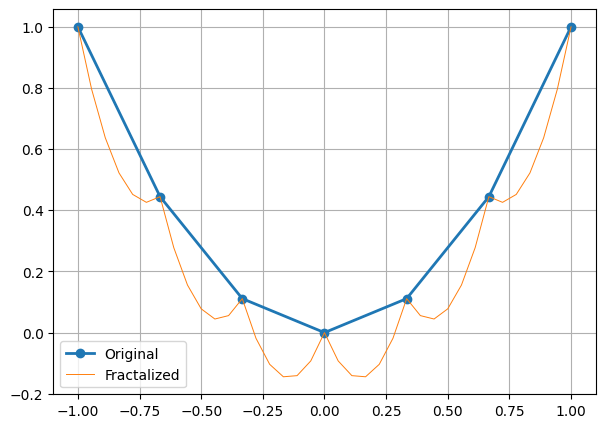

In [6]:
import matplotlib.pyplot as plt

X = np.linspace(-1, 1, 7)
Y = X**2

alpha = np.array([0.2,0.2, 0.2, 0.2, 0.2, 0.2], dtype=float)
# alpha = 0.2
x, fractal_Y = fractalize(X, Y, alpha, n_iter=1)
print(x)
print(fractal_Y)
plt.figure(figsize=(7,5))
plt.plot(X, Y, 'o-', lw=2, label='Original')
plt.plot(x, fractal_Y, label='Fractalized', linewidth=0.7)
plt.legend()
plt.grid(True)
plt.show()

$$
\textbf{Given data points } \{(X_i,Y_i)\}_{i=0}^{N}, \quad N = \mathrm{len}(X)-1,
$$
with
$$
x_0 = X_0,\qquad x_N = X_N,\qquad y_0 = Y_0,\qquad y_N = Y_N.
$$

Let the vertical scaling parameters be
$$
\alpha_0,\alpha_1,\dots,\alpha_{N-1},
$$
where either
$$
\alpha_n = \alpha \quad \text{for all } n
$$
if a single float is provided, or else $\alpha_n$ is given individually.

For each $n=0,1,\dots,N-1$, define the affine coefficients
$$
a_n = \frac{X_{n+1}-X_n}{x_N-x_0},
$$
$$
b_n = \frac{x_N X_n - x_0 X_{n+1}}{x_N-x_0},
$$
$$
c_n = \frac{Y_{n+1}-Y_n-\alpha_n (y_N-y_0)}{x_N-x_0},
$$
$$
d_n = \frac{x_N Y_n - x_0 Y_{n+1} - \alpha_n (x_N y_0 - x_0 y_N)}{x_N-x_0}.
$$

Then the iterated function system (IFS) consists of maps
$$
w_n : \mathbb{R}^2 \to \mathbb{R}^2,
$$
given by
$$
w_n(x,y)
=
\begin{pmatrix}
a_n x + b_n \\
\alpha_n y + c_n x + d_n
\end{pmatrix},
\qquad n=0,1,\dots,N-1.
$$

Starting from the initial set of points
$$
P^{(0)} = \{(X_i,Y_i)\}_{i=0}^{N},
$$
the iteration is defined by
$$
P^{(k+1)} = \bigcup_{n=0}^{N-1} w_n\bigl(P^{(k)}\bigr),
\qquad k=0,1,\dots,n_{\mathrm{iter}}-1.
$$

Equivalently, if
$$
P^{(k)} = \{p_1^{(k)},p_2^{(k)},\dots,p_{M_k}^{(k)}\},
$$
then
$$
P^{(k+1)}
=
\left\{
w_n\!\left(p_j^{(k)}\right)
:\;
n=0,\dots,N-1,\;
j=1,\dots,M_k
\right\}.
$$

After $n_{\mathrm{iter}}$ iterations, the resulting set
$$
P^{(n_{\mathrm{iter}})}
$$
is sorted by increasing $x$-coordinate. If
$$
P^{(n_{\mathrm{iter}})} = \{(x_i,r_i)\}_{i=1}^{M}
$$
after sorting, then the function returns
$$
x = (x_1,\dots,x_M),
\qquad
r = (r_1,\dots,r_M).
$$